# Churn Prediction with XGBClassifier

In this Notebook my main focus was to get more familiar with XGB and Paramtertuning. Therfore I build a model to predict if customors churn or not. 

*  [Preprocessing](#Preprocessing)
*  [Parameter Tuning](#Parameter-Tuning)
*  [Results](#Results)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score,roc_curve,accuracy_score
from sklearn.model_selection import RandomizedSearchCV,train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
import scipy.stats as stats
import xgboost as xgb

In [2]:
df = pd.read_csv('/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Since we have a lot of columns with the dtype object we will have ro convert these into numerical columns through an encoder.

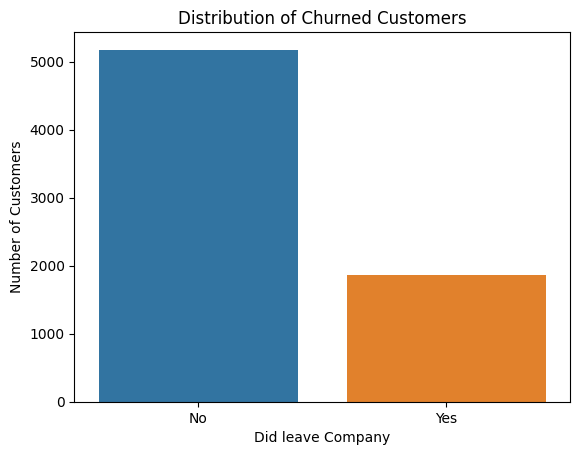

In [6]:
sns.countplot(data=df, x="Churn",hue="Churn")
plt.title('Distribution of Churned Customers')
plt.ylabel('Number of Customers')
plt.xlabel('Did leave Company')
plt.show()

## Preprocessing

In [7]:
# Handle NaN values
df["MonthlyCharges"] == pd.to_numeric(df["MonthlyCharges"],errors='coerce')
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
label_encoder = LabelEncoder()
object_columns = df.select_dtypes('object')

for col in object_columns:
    df[col] = label_encoder.fit_transform(df[col])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   int64  
 1   gender            7043 non-null   int64  
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   int64  
 4   Dependents        7043 non-null   int64  
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   int64  
 7   MultipleLines     7043 non-null   int64  
 8   InternetService   7043 non-null   int64  
 9   OnlineSecurity    7043 non-null   int64  
 10  OnlineBackup      7043 non-null   int64  
 11  DeviceProtection  7043 non-null   int64  
 12  TechSupport       7043 non-null   int64  
 13  StreamingTV       7043 non-null   int64  
 14  StreamingMovies   7043 non-null   int64  
 15  Contract          7043 non-null   int64  
 16  PaperlessBilling  7043 non-null   int64  


In [9]:
X = df.iloc[:,:-1] # extract last Column which is the targert churn
y = df.iloc[:,-1]
scaler = StandardScaler()
X_train,X_test,y_train,y_test = train_test_split(X,y,stratify=y,test_size=0.2,random_state=42)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
dmatrix_train = xgb.DMatrix(X_train_scaled,y_train)
dmatrix_test = xgb.DMatrix(X_test_scaled,y_test)

In [10]:
param = {'max_depth': 2,  
         'objective': 'binary:logistic',
         'learning_rate':0.1
        }
rounds=50
model = xgb.train(param,dmatrix_train,num_boost_round=rounds)

In [11]:
preds = model.predict(dmatrix_test)
preds = (preds >= 0.5).astype(int) # we will will go with the conservative threshold for now
preds_proba = model.predict(dmatrix_test)
preds_proba_train = model.predict(dmatrix_train)
preds = (preds_proba >= 0.5).astype(int) # we will will go with the conservative threshold for now
accuracy = accuracy_score(y_test,preds)
roc_score = roc_auc_score(y_test, preds_proba)
roc_score_train = roc_auc_score(y_train, preds_proba_train)
print('Accuracy is: ',accuracy)
print('Roc score: ',roc_score) # ROC score without parametertuning
print('Roc score train:' , roc_score_train)

Accuracy is:  0.7955997161107168
Roc score:  0.8409956340902632
Roc score train: 0.8557998353212488


In [12]:
idx = model.get_score(importance_type='weight')
columns = []
for i,values in enumerate(idx.keys()):
    index = int(values[1:])
    key = df.columns[index]
    columns.append(df.columns[index])
fi = pd.DataFrame(data=list(idx.values()),index=columns,columns=['Importance']).sort_values(by='Importance',ascending=False)

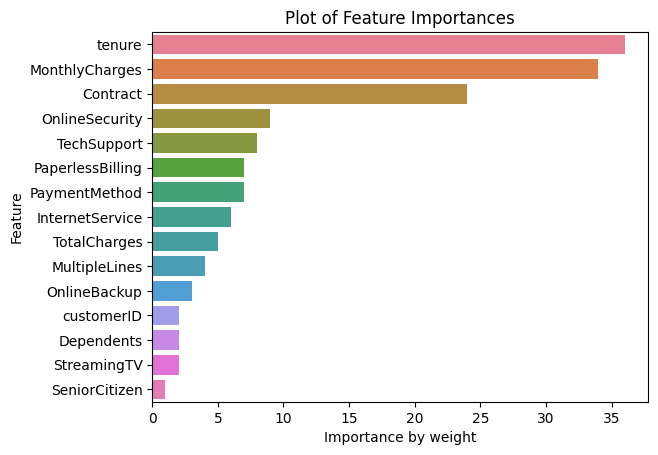

In [13]:
sns.barplot(data=fi,x='Importance',y=fi.index,hue=fi.index)
plt.title('Plot of Feature Importances')
plt.ylabel('Feature')
plt.xlabel('Importance by weight')
plt.show()

## Parameter Tuning

In [14]:
scale_pos_weight = sum(y_train == 0) / sum(y_train == 1)
param_dist = {
    "max_depth": stats.randint(2, 6),                 
    "learning_rate": stats.uniform(0.01, 0.02),       
    "subsample": stats.uniform(0.8, 0.2),             
    "colsample_bytree": stats.uniform(0.6, 0.4),  
    "reg_lambda": stats.uniform(1.4,0.5),
    "reg_alpha" : stats.uniform(0.8, 0.4),
    "max_delta_step": stats.randint(6, 10),
    "n_estimators" : stats.randint(111,300),
    "gamma": stats.uniform(0.1,0.5),
    "min_child_weight" : stats.randint(1, 7),
    "colsample_bytree" : [ 0.3, 0.4, 0.5 , 0.7 ]
}
model = xgb.XGBClassifier(objective='binary:logistic',eval_metric="auc",random_state=42,scale_pos_weight=scale_pos_weight)
random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=50,                 
    scoring="roc_auc",
    cv=5,
    #verbose=1,
    n_jobs=-1,
    random_state=42
)
random_search.fit(X_train_scaled,y_train)
print("Best Parameters: ",random_search.best_params_)
print("Best Score: ",random_search.best_score_)


Best Parameters:  {'colsample_bytree': 0.5, 'gamma': np.float64(0.4629778394351197), 'learning_rate': np.float64(0.027942205199051544), 'max_delta_step': 9, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 262, 'reg_alpha': np.float64(1.1403713795070052), 'reg_lambda': np.float64(1.8678174971104737), 'subsample': np.float64(0.9570681302227888)}
Best Score:  0.8487021082977954


## Results

In [15]:
# Probabilites
p_test = random_search.predict_proba(X_test)[:, 1]
p_train = random_search.predict_proba(X_train)[:,1]

# Accuracy
preds_train = random_search.predict(X_train)
preds_test = random_search.predict(X_test)
preds_train = (preds_train >= 0.5).astype(int)
preds_test = (preds_test >= 0.5).astype(int)
# Calculating Scores
accuracy_train = accuracy_score(y_train,preds_train)
accuracy_test = accuracy_score(y_test,preds_test)
roc_score = roc_auc_score(y_test, p_test)
roc_score_train = roc_auc_score(y_train, p_train)

print('Accuracy train is: ',accuracy_train)
print('Accuracy test is: ',accuracy_test)
print('Roc score train:', roc_score_train)
print('Roc score test: ',roc_score)

Accuracy train is:  0.7845225417110401
Accuracy test is:  0.7686302342086586
Roc score train: 0.8265064913971918
Roc score test:  0.8113513653155597


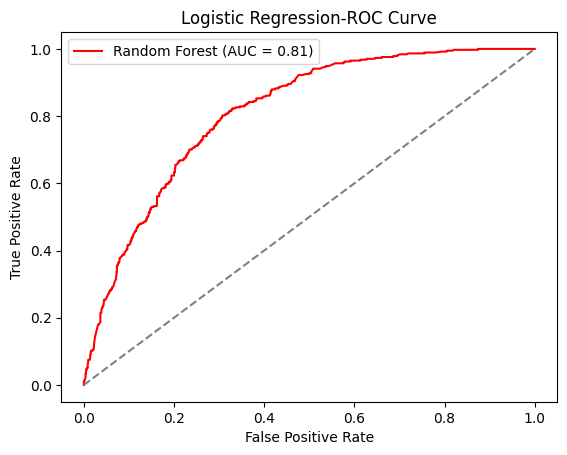

In [16]:
fpr_lr ,tpr_lr, _ = roc_curve(y_test,p_test)
plt.plot(fpr_lr,tpr_lr,label=f"Random Forest (AUC = {roc_score:.2f})",color='Red')
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.title("Logistic Regression-ROC Curve")
plt.show()